In [1]:
import typing as tp

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.func import functional_call, hessian
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

import numpy as np

import copy

from soap import SOAP

In [2]:
def make_hessian(
    model: nn.Module, x: tuple, y: torch.Tensor, loss_fn: tp.Callable
) -> tp.Any:
    """Computes the Hessian of `model` evaluated at `x`.

    Args:
        model (nn.Module): A neural network
        x (tuple): inputs to the network s.t. model(*x) is a valid statement
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)

    Returns:
        tp.Any: Hessian
    """

    # Zero existing gradients
    for p in model.parameters():
        p.grad = None
    
    # Ensure model is in training mode for proper gradient computation
    model.train()

    make_loss = lambda params, x, y: loss_fn(functional_call(model, params, x), y)

    params = dict(model.named_parameters())
    # This returns a nested dictionary of dictionaries
    hess_dict: dict[str, dict[str, torch.Tensor]] = hessian(make_loss)(params, x, y)

    # Effective shape: (num_params, num_params)
    # example: A linear model mapping R^4 -> R with bias has 2 parameters: weight and bias.
    # within these there are 5 elements (4 in weight, 1 in bias). So `hess_dict` is a dict of
    # dicts, with the keys mapping to different blocks of the hessian matrix: dict[i][j] gives
    # grad_i ( grad_j (loss) )  [order might be off here, but i think it should be symmetric anyway]
    # The shapes of these (after flattening) are H_ww: (4, 4), H_wb: (4, 1), H_bw: (1, 4), H_bb: (1, 1) in this example
    # These form the four blocks of the full Hessian matrix of shape (5, 5).
    #
    #   --------------------
    #   |           |      |
    #   |   H_ww    | H_wb |
    #   |           |      |
    #   |           |      |
    #   |------------------|
    #   | H_bw      | H_bb |
    #   --------------------

    named_params = {k: v for k, v in model.named_parameters()}
    # Important that order of parameters is consistent
    param_names = sorted(list(named_params.keys()))
    param_count = sum(p.numel() for p in named_params.values())
    # hess_mat = torch.empty((param_count, param_count))
    with torch.no_grad():
        hess_mat = torch.full(
            (param_count, param_count),
            float("nan"),
            device=next(model.parameters()).device,  # assume all on same device
        )
        cur_row = 0
        for i_key in param_names:
            cur_col = 0
            block_height = 0
            for j_key in param_names:
                # shape: (*param_i.shape, *param_j.shape)
                hess_block_ij = hess_dict[i_key][j_key]

                # reshape to 2D matrix
                hess_block_ij = hess_block_ij.reshape(
                    named_params[i_key].numel(), named_params[j_key].numel()
                )
                block_height = hess_block_ij.shape[0]
                hess_mat[
                    cur_row : cur_row + hess_block_ij.shape[0],
                    cur_col : cur_col + hess_block_ij.shape[1],
                ] = hess_block_ij
                cur_col += hess_block_ij.shape[1]
            cur_row += block_height

    return hess_mat


def make_gradient(
    model: nn.Module, x: tuple, y: torch.Tensor, loss_fn: tp.Callable
) -> torch.Tensor:
    """Computes the gradient of `model` evaluated at `x`. I'm sure there should be a
    way to rewrite the Hessian computation to produce this as a byproduct, but
    I don't feel like figuring it out right now.

    Args:
        model (nn.Module): A neural network
        x (tuple): inputs to the network s.t. model(*x) is a valid statement
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)

    Returns:
        torch.Tensor: Gradient
    """
    # Zero existing gradients
    for p in model.parameters():
        p.grad = None
    
    # Ensure model is in training mode for proper gradient computation
    model.train()

    outputs = model(*x)
    loss = loss_fn(outputs, y)
    loss.backward()

    named_params = list(model.named_parameters())
    named_params.sort(key=lambda tup: tup[0])  # sort by name for consistency
    return torch.cat([p.grad.flatten() for _, p in named_params])


def make_newton_step(
    model: nn.Module,
    x: tuple,
    y: torch.Tensor,
    loss_fn: tp.Callable,
    update_params: bool = True,
    clip_step_size: float | None = 1.0,
) -> dict[str, torch.Tensor]:
    """Runs one step of Newton's algorithm on a model with parameters `params`.
    The parameters will be optionally modified in-place and the computed
    optimization step is returned for each parameter.

    Args:
        model (nn.Module): The neural network model
        x (tuple): Inputs to the network
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)
        update_params (bool, optional): Whether to update the parameters in-place. Defaults to True.

    Returns:
        list[torch.Tensor]: Optimal step for each parameter.
    """
    hessian = make_hessian(model, x, y, loss_fn)
    gradient = make_gradient(model, x, y, loss_fn)
    # Ultimately, we want the inverse hessian-gradient product:  -H^{-1} g
    with torch.no_grad():
        hgp = -torch.linalg.lstsq(hessian, gradient).solution
    if clip_step_size is not None:
        step_norm = torch.norm(hgp)
        if step_norm > clip_step_size:
            hgp = hgp * clip_step_size / step_norm

    # Split the flat hgp into parameter-shaped chunks
    named_params = list(model.named_parameters())
    named_params.sort(key=lambda tup: tup[0])  # sort by name for consistency
    numels = [p.numel() for _, p in named_params]
    updates = torch.split(hgp, numels)

    param_steps = {
        name: step.reshape(param.shape)
        for (name, param), step in zip(named_params, updates)
    }

    if update_params:
        # Update parameters in-place
        with torch.no_grad():
            for name, param in model.named_parameters():
                param += param_steps[name]

    return param_steps

def compute_newton_update(
    model: nn.Module,
    x: tuple,
    y: torch.Tensor,
    loss_fn: tp.Callable,
    update_params: bool = True,
    clip_step_size: float | None = 1.0,
    reg: float = 1e-3,
    debug: bool = False,
) -> torch.Tensor:
    """Runs the update provided by one step of Newton's algorithm on a model with parameters `params`.
    The parameters will be optionally modified in-place and the computed
    optimization step is returned for each parameter.

    Args:
        model (nn.Module): The neural network model
        x (tuple): Inputs to the network
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)
        update_params (bool, optional): Whether to update the parameters in-place. Defaults to True.
        reg (float, optional): Regularization term to add to Hessian diagonal. Defaults to 1e-4.
        debug (bool, optional): Print debug information. Defaults to False.

    Returns:
        list[torch.Tensor]: Optimal step for each parameter.
    """
    hessian = make_hessian(model, x, y, loss_fn)
    gradient = make_gradient(model, x, y, loss_fn)
    
    # Add regularization to make Hessian invertible (Levenberg-Marquardt style)
    # This is especially important for classification with ReLU where Hessian can be singular
    with torch.no_grad():
        # Check for NaN or Inf in Hessian
        if debug:
            print(f"Debug - Hessian has NaN: {torch.isnan(hessian).any().item()}")
            print(f"Debug - Hessian has Inf: {torch.isinf(hessian).any().item()}")
            print(f"Debug - Hessian min: {hessian.min().item():.6f}, max: {hessian.max().item():.6f}")
            print(f"Debug - Hessian diagonal min: {torch.diag(hessian).min().item():.6f}, max: {torch.diag(hessian).max().item():.6f}")
        
        # Check gradient norm first
        grad_norm = torch.norm(gradient).item()
        if debug:
            print(f"Debug - Gradient norm: {grad_norm:.6f}")
        
        # If gradient is very small, return zero update
        if grad_norm < 1e-8:
            return torch.zeros(sum(p.numel() for p in model.parameters()), device=gradient.device, dtype=gradient.dtype)
        
        # Add regularization to diagonal - use adaptive regularization based on gradient norm
        # Higher regularization for better conditioning
        hessian_reg = hessian + reg * torch.eye(hessian.shape[0], device=hessian.device, dtype=hessian.dtype)
        
        # Compute condition number once
        cond_num = torch.linalg.cond(hessian_reg).item()
        if debug:
            print(f"Debug - Condition number (regularized): {cond_num:.2e}")
        
        # Solve: H_reg * hgp = -gradient, so hgp = -H_reg^{-1} * gradient
        # Use different solvers based on condition number
        try:
            
            if cond_num < 1e8:
                # Well-conditioned: use direct solve
                hgp = -torch.linalg.solve(hessian_reg, gradient)
            elif cond_num < 1e12:
                # Moderately ill-conditioned: use lstsq with reasonable rcond
                result = torch.linalg.lstsq(hessian_reg, gradient, rcond=1e-4)
                hgp = -result.solution
            else:
                # Very ill-conditioned: use pseudo-inverse with cutoff
                # This is more expensive but more robust
                hessian_pinv = torch.linalg.pinv(hessian_reg, rcond=1e-4)
                hgp = -hessian_pinv @ gradient
            
            hgp_norm = torch.norm(hgp).item()
            residual = hessian_reg @ hgp + gradient
            residual_norm = torch.norm(residual).item()
            
            if debug:
                print(f"Debug - HGP norm: {hgp_norm:.6f}")
                print(f"Debug - Residual norm: {residual_norm:.6f}")
                print(f"Debug - Relative residual: {residual_norm / grad_norm:.6f}")
            
            # If the solution is essentially zero, something went wrong
            # Note: High residual is okay for ill-conditioned systems - we still use the solution
            if hgp_norm < 1e-10:
                if debug:
                    print(f"Debug - HGP norm too small, returning zero")
                hgp = torch.zeros_like(gradient)
            elif debug and (residual_norm / grad_norm) > 0.5:
                print(f"Debug - Warning: High relative residual ({residual_norm / grad_norm:.3f}), solution may be inaccurate")
                
        except Exception as e:
            if debug:
                print(f"Debug - Linear solve failed: {e}")
            hgp = torch.zeros_like(gradient)
    
    return hgp.clone()

In [3]:
import torchvision
import torchvision.transforms as transforms

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 images to 784
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
torch.manual_seed(42)

d_data = 784
num_epochs = 500
dataset_size = 2000
batch_size = 10
hidden_dim = 10

#model = nn.Linear(d_data, 1)
model = nn.Sequential(nn.Linear(d_data, hidden_dim, bias=False), nn.ReLU(), nn.Linear(hidden_dim, 10, bias=False))

loss = nn.CrossEntropyLoss()

dataset = mnist_train
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
losses = []
cos_sims = []
verbose = True
num_epochs = 1
lr = 1e-2
clip = False

# Initialize model weights with better initialization
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

opt = SOAP(model.parameters(), lr=1e-3)
#opt = optim.SGD(model.parameters(), lr=1e-3)
#opt = optim.Adam(model.parameters(), lr=1e-3)
#opt = optim.Muon(model.parameters(), lr=lr)

for step in range(num_epochs):
    epoch_losses = []
    for batch_idx, (data, targets) in enumerate(dataloader):
        # compute newton update on a copy of everything to not mess with the model graph
        model_copy = copy.deepcopy(model)
        
        # Debug: check gradient and Hessian before computing update
        if verbose and batch_idx == 0 and step == 0:
            # Check gradient directly
            model_copy.eval()
            outputs_debug = model_copy(data)
            loss_debug = loss(outputs_debug, targets)
            loss_debug.backward()
            grad_debug = torch.cat([p.grad.flatten() for p in model_copy.parameters()])
            print(f"Debug - Gradient norm: {torch.norm(grad_debug).item():.6f}")
            print(f"Debug - Loss value: {loss_debug.item():.6f}")
            print(f"Debug - Output range: [{outputs_debug.min().item():.4f}, {outputs_debug.max().item():.4f}]")
            model_copy.zero_grad()
        
        newton_update = compute_newton_update(model_copy, (data,), targets, loss, debug=(verbose and batch_idx < 3 and step == 0))
        del model_copy
        # get model parameters as a vector
        with torch.no_grad():
            params_copy_old = torch.cat([p.data.flatten() for p in model.parameters()]).clone()
        # apply loss backward / optimizer step / zero grads
        outputs = model(data)  # Recompute outputs for current batch
        train_loss = loss(outputs, targets)
        train_loss.backward()
        # Add gradient clipping to prevent exploding gradients
        if clip: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        opt.step()
        opt.zero_grad()
        with torch.no_grad():
            params_copy_new = torch.cat([p.data.flatten() for p in model.parameters()]).clone()

            # check param change
            param_change = params_copy_new - params_copy_old
            if verbose: print(f"Param change norm {torch.norm(param_change).item():.4f}")
            if verbose: print(f"hgp norm {torch.norm(newton_update).item():.4f}")

            # check cos similarity between newton update and param change
            cos_sim = torch.nn.functional.cosine_similarity(newton_update, param_change, dim=0)
            cos_sims.append(cos_sim.item())
            if verbose: print(f"Cosine similarity {cos_sim.item():.4f}")

        # Record and print loss for each batch
        epoch_losses.append(train_loss.item())
        print(f"Epoch {step}, Batch loss: {train_loss.item():.4f}")
        break

    # After each epoch, append average loss to losses
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {step}: Average train loss {avg_loss:.4f}")

Debug - Gradient norm: 1.575955
Debug - Loss value: 2.203783
Debug - Output range: [-0.9924, 1.0683]
Debug - Hessian has NaN: False
Debug - Hessian has Inf: False
Debug - Hessian min: -0.272847, max: 0.142841
Debug - Hessian diagonal min: 0.000000, max: 0.081480
Debug - Gradient norm: 1.575955
Debug - Condition number (regularized): 1.09e+05
Debug - HGP norm: 26.138554
Debug - Residual norm: 0.000432
Debug - Relative residual: 0.000274
Param change norm 0.0000
hgp norm 26.1386
Cosine similarity 0.0000
Epoch 0, Batch loss: 2.2038
Epoch 0: Average train loss 2.2038


ValueError: x and y must have same first dimension, but have shapes (0,) and (3,)

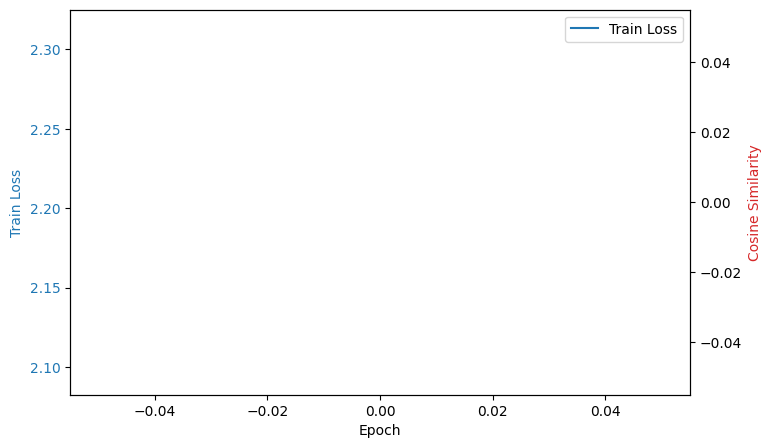

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(range(len(losses)), losses, color=color, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Calculate total number of steps (batches) and batches per epoch for x-scaling
num_train_batches = len(cos_sims) // (len(losses) - 1) if len(losses) > 1 else len(cos_sims)
batch_steps = np.arange(len(cos_sims)) / num_train_batches  # fractional epoch for each batch

# Plot cosine similarity in light red
light_red = '#ff9999'
ax2.set_ylabel('Cosine Similarity', color='tab:red')
ax2.plot(batch_steps, cos_sims, color=light_red, linestyle='--', label='Cosine Similarity')

# Compute and plot moving average in dark red
window_size = 25 if len(cos_sims) > 50 else max(3, len(cos_sims)//10)
cos_sims_ma = np.convolve(cos_sims, np.ones(window_size)/window_size, mode='valid')
batch_steps_ma = batch_steps[window_size-1:]
dark_red = '#b22222'
ax2.plot(batch_steps_ma, cos_sims_ma, color=dark_red, label=f'Moving Average (window={window_size})')

ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper left')

fig.tight_layout()
plt.title('Training Loss (per Epoch) and Cosine Similarity (3 Layer) (per Batch) vs Epoch (Muon)')
plt.show()
